# Captcha Recognition with CNN + CTC

Complete pipeline: Data Exploration → Preprocessing → Model → Training → Evaluation → Prediction

## 1. Data Exploration

In [25]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
import random

# Configuration
DATA_DIR = 'data/samples'
IMG_HEIGHT = 32
IMG_WIDTH = 128
MAX_LABEL_LENGTH = 5

# Load all image files
files = sorted(os.listdir(DATA_DIR))
print(f"Total samples: {len(files)}")
print(f"Sample files: {files[:5]}")

Total samples: 1070
Sample files: ['226md.png', '22d5n.png', '2356g.png', '23mdg.png', '23n88.png']


In [26]:
# Check image properties
sample_img = Image.open(os.path.join(DATA_DIR, files[0]))
print(f"Image size: {sample_img.size}")
print(f"Image mode: {sample_img.mode}")

# Extract labels from filenames
labels = [os.path.splitext(f)[0] for f in files]

# Character analysis
all_chars = ''.join(labels)
unique_chars = sorted(set(all_chars))
char_to_idx = {c: i + 1 for i, c in enumerate(unique_chars)}  # 0 reserved for blank
idx_to_char = {i + 1: c for i, c in enumerate(unique_chars)}
idx_to_char[0] = ''  # Blank token

print(f"\nUnique characters: {len(unique_chars)}")
print(f"Character set: {unique_chars}")
print(f"\nCharacter to index mapping: {char_to_idx}")

Image size: (200, 50)
Image mode: RGBA

Unique characters: 19
Character set: ['2', '3', '4', '5', '6', '7', '8', 'b', 'c', 'd', 'e', 'f', 'g', 'm', 'n', 'p', 'w', 'x', 'y']

Character to index mapping: {'2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, 'b': 8, 'c': 9, 'd': 10, 'e': 11, 'f': 12, 'g': 13, 'm': 14, 'n': 15, 'p': 16, 'w': 17, 'x': 18, 'y': 19}


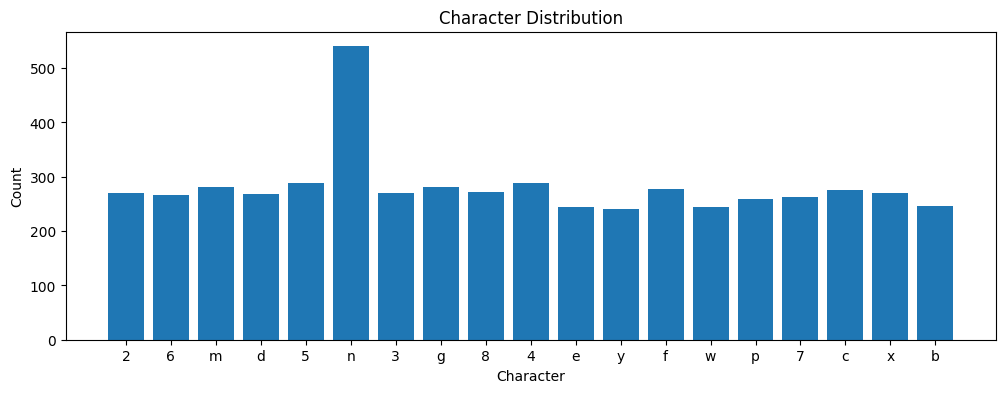


All labels have length: {5}
Unique labels: 1070


In [27]:
# Character distribution
char_counts = Counter(all_chars)

plt.figure(figsize=(12, 4))
plt.bar(char_counts.keys(), char_counts.values())
plt.title('Character Distribution')
plt.xlabel('Character')
plt.ylabel('Count')
plt.show()

# Length distribution
lengths = [len(label) for label in labels]
print(f"\nAll labels have length: {set(lengths)}")
print(f"Unique labels: {len(set(labels))}")

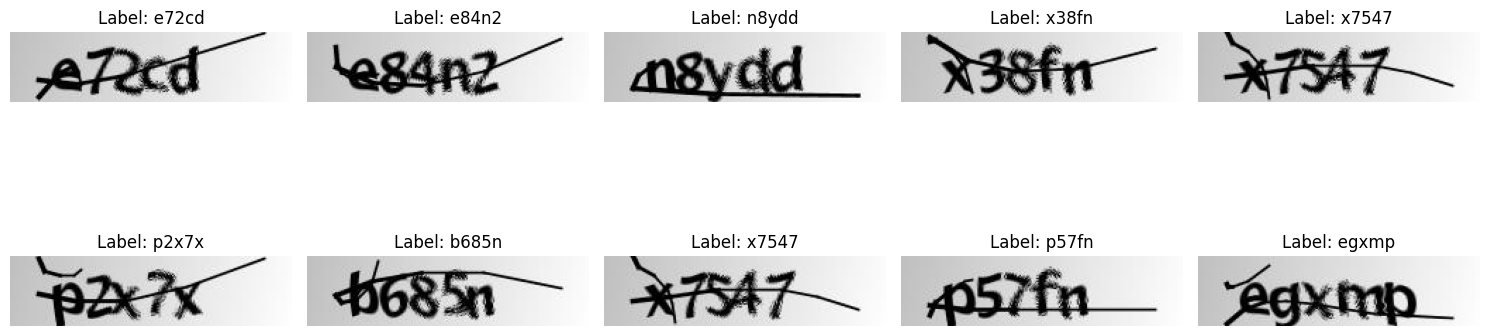

In [28]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    idx = random.randint(0, len(files) - 1)
    img = Image.open(os.path.join(DATA_DIR, files[idx]))
    label = labels[idx]
    ax.imshow(img)
    ax.set_title(f'Label: {label}', fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Data Preprocessing



In [29]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import torch.nn as nn

# Dataset class
class CaptchaDataset(Dataset):
    def __init__(self, file_list, data_dir, char_to_idx, transform=None):
        self.file_list = file_list
        self.data_dir = data_dir
        self.char_to_idx = char_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]
        label = os.path.splitext(filename)[0]
        img_path = os.path.join(self.data_dir, filename)
        image = Image.open(img_path).convert('L')

        if self.transform:
            image = self.transform(image)

        label_indices = [self.char_to_idx[c] for c in label]
        return image, torch.tensor(label_indices, dtype=torch.long), len(label_indices)

# Train/Validation/Test split (80/10/10)
indices = list(range(len(files)))
train_val_idx, test_idx = train_test_split(indices, test_size=0.1, random_state=42)
train_idx, val_idx = train_test_split(train_val_idx, test_size=1/9, random_state=42)  # 0.1 of 0.9 = ~0.111

train_files = [files[i] for i in train_idx]
val_files = [files[i] for i in val_idx]
test_files = [files[i] for i in test_idx]

print(f"Training samples: {len(train_files)}")
print(f"Validation samples: {len(val_files)}")
print(f"Test samples: {len(test_files)}")

Training samples: 856
Validation samples: 107
Test samples: 107


In [30]:


base_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Training augmentation (applied after resize)
train_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomAffine(
        degrees=5,           # Rotate slightly
        translate=(0.05, 0.1),  # Small horizontal/vertical shift
        scale=(0.9, 1.1),    # Slight zoom
        shear=5              # Shear transform
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1))  # Random noise patches
])

# Create datasets - training uses augmentation, val/test use base transform
train_dataset = CaptchaDataset(train_files, DATA_DIR, char_to_idx, train_transform)
val_dataset = CaptchaDataset(val_files, DATA_DIR, char_to_idx, base_transform)
test_dataset = CaptchaDataset(test_files, DATA_DIR, char_to_idx, base_transform)

# Create data loaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 27
Val batches: 4
Test batches: 4


In [31]:
# (Duplicate - skipped)

## 3. Build Model

In [32]:
# Number of classes (19 chars + 1 blank)
NUM_CLASSES = len(unique_chars) + 1
print(f"NUM_CLASSES: {NUM_CLASSES}")

# Simple CNN + Linear for CTC (NO LSTM - avoids collapse)
class SimpleCTC(nn.Module):
    def __init__(self, num_classes, num_channels=64):
        super().__init__()

        # CNN to extract features
        self.cnn = nn.Sequential(
            nn.Conv2d(1, num_channels, 3, padding=1), nn.BatchNorm2d(num_channels), nn.ReLU(),
            nn.Conv2d(num_channels, num_channels, 3, padding=1), nn.BatchNorm2d(num_channels), nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 128 -> 64

            nn.Conv2d(num_channels, num_channels*2, 3, padding=1), nn.BatchNorm2d(num_channels*2), nn.ReLU(),
            nn.Conv2d(num_channels*2, num_channels*2, 3, padding=1), nn.BatchNorm2d(num_channels*2), nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 64 -> 32

            nn.Conv2d(num_channels*2, num_channels*4, 3, padding=1), nn.BatchNorm2d(num_channels*4), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, None)),  # (B, 256, 1, T)
        )

        # Output projection
        self.fc = nn.Linear(num_channels*4, num_classes)

    def forward(self, x):
        conv = self.cnn(x)  # (B, 256, 1, T)
        conv = conv.squeeze(2)  # (B, 256, T)
        conv = conv.permute(0, 2, 1)  # (B, T, 256)
        out = self.fc(conv)  # (B, T, num_classes)
        out = out.permute(1, 0, 2)  # (T, B, num_classes)
        return out

# Create model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = SimpleCTC(NUM_CLASSES).to(device)

# Test model
dummy_input = torch.randn(2, 1, IMG_HEIGHT, IMG_WIDTH)
output = model(dummy_input)
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}  (T=time_steps, B=batch, C=classes)")

NUM_CLASSES: 20
Using device: cpu
Input shape: torch.Size([2, 1, 32, 128])
Output shape: torch.Size([32, 2, 20])  (T=time_steps, B=batch, C=classes)


## 4. CTC Decode Function

In [33]:
# CTC Decode - Greedy decoding
def decode(outputs, idx_to_char, max_len=5):
    """Decode CTC output to text"""
    _, max_idx = torch.max(outputs, dim=2)  # (T, B)
    max_idx = max_idx.permute(1, 0).cpu().numpy()  # (B, T)

    decoded = []
    for seq in max_idx:
        chars = []
        prev = -1
        for idx in seq:
            idx = int(idx)
            # Skip blank (0) and consecutive duplicates
            if idx != 0 and idx != prev:
                chars.append(idx_to_char.get(idx, ''))
            prev = idx
        # Take only first max_len chars
        decoded.append(''.join(chars[:max_len]))
    return decoded

## 5. Training

In [34]:
# Training setup
criterion = nn.CTCLoss(zero_infinity=True)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels, label_lengths in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        # CTC loss
        input_lengths = torch.full((images.size(0),), outputs.size(0), dtype=torch.long)
        targets = labels.view(-1)
        loss = criterion(outputs.log_softmax(2), targets, input_lengths, label_lengths)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()

        # Calculate accuracy
        preds = decode(outputs, idx_to_char, MAX_LABEL_LENGTH)
        for b in range(images.size(0)):
            true = ''.join([idx_to_char[i.item()] for i in labels[b][:label_lengths[b]]])
            if preds[b] == true:
                correct += 1
            total += 1

    return total_loss / len(loader), correct / total

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels, label_lengths in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            input_lengths = torch.full((images.size(0),), outputs.size(0), dtype=torch.long)
            targets = labels.view(-1)
            loss = criterion(outputs.log_softmax(2), targets, input_lengths, label_lengths)
            total_loss += loss.item()

            preds = decode(outputs, idx_to_char, MAX_LABEL_LENGTH)
            for b in range(images.size(0)):
                true = ''.join([idx_to_char[i.item()] for i in labels[b][:label_lengths[b]]])
                if preds[b] == true:
                    correct += 1
                total += 1

    return total_loss / len(loader), correct / total

# Test evaluation function
def evaluate_on_test(model, loader, device):
    """Evaluate on held-out test set (never seen during training/validation)"""
    model.eval()
    correct = 0
    total = 0
    predictions = []

    with torch.no_grad():
        for images, labels, label_lengths in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = decode(outputs, idx_to_char, MAX_LABEL_LENGTH)

            for b in range(images.size(0)):
                true = ''.join([idx_to_char[i.item()] for i in labels[b][:label_lengths[b]]])
                is_correct = preds[b] == true
                if is_correct:
                    correct += 1
                total += 1
                predictions.append({
                    'true': true,
                    'pred': preds[b],
                    'correct': is_correct
                })

    return correct / total, predictions

In [35]:
# Training loop with 80/10/10 split
NUM_EPOCHS = 50
best_val_acc = 0
best_test_acc = 0
best_model_path = 'best_ctc_model.pth'

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Update learning rate scheduler
    scheduler.step(val_acc)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train: {train_loss:.4f}, {train_acc:.2%} | Val: {val_loss:.4f}, {val_acc:.2%} | LR: {optimizer.param_groups[0]['lr']:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        # Evaluate on test set
        test_acc, _ = evaluate_on_test(model, test_loader, device)
        best_test_acc = test_acc
        print(f"  -> Saved best model! (Val: {best_val_acc:.2%}, Test: {best_test_acc:.2%})")

    # Show samples every 10 epochs
    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            imgs, lbls, lbl_lens = next(iter(val_loader))
            outs = model(imgs.to(device))
            preds = decode(outs, idx_to_char, MAX_LABEL_LENGTH)
        for b in range(3):
            true = ''.join([idx_to_char[i.item()] for i in lbls[b][:lbl_lens[b]]])
            print(f"    Sample: '{preds[b]}' vs '{true}'")

print(f"\nTraining complete!")
print(f"Best Val Accuracy: {best_val_acc:.2%}")
print(f"Best Test Accuracy: {best_test_acc:.2%}")

Epoch 1/50 | Train: 8.1840, 0.00% | Val: 3.6890, 0.00% | LR: 0.001000
Epoch 2/50 | Train: 3.3571, 0.00% | Val: 3.2461, 0.00% | LR: 0.001000
Epoch 3/50 | Train: 3.1117, 0.00% | Val: 2.9602, 0.00% | LR: 0.001000
Epoch 4/50 | Train: 2.6671, 0.00% | Val: 2.8683, 0.00% | LR: 0.001000
Epoch 5/50 | Train: 1.6663, 2.22% | Val: 1.0933, 3.74% | LR: 0.001000
  -> Saved best model! (Val: 3.74%, Test: 1.87%)
Epoch 6/50 | Train: 0.6690, 50.70% | Val: 0.2856, 84.11% | LR: 0.001000
  -> Saved best model! (Val: 84.11%, Test: 77.57%)
Epoch 7/50 | Train: 0.3059, 77.45% | Val: 0.1355, 94.39% | LR: 0.001000
  -> Saved best model! (Val: 94.39%, Test: 93.46%)
Epoch 8/50 | Train: 0.2013, 85.05% | Val: 0.1444, 90.65% | LR: 0.001000
Epoch 9/50 | Train: 0.1399, 89.84% | Val: 0.0565, 98.13% | LR: 0.001000
  -> Saved best model! (Val: 98.13%, Test: 95.33%)
Epoch 10/50 | Train: 0.1173, 90.07% | Val: 0.0696, 92.52% | LR: 0.001000
    Sample: '8bbw8' vs '8bbw8'
    Sample: 'n5cm7' vs 'n5cm7'
    Sample: 'g2fnw' vs 'g

## 6. Evaluation on Test Set

In [36]:
# Load best model and evaluate on held-out test set
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# Final evaluation on both validation and test sets
val_loss, val_acc = validate(model, val_loader, criterion, device)
test_acc, test_predictions = evaluate_on_test(model, test_loader, device)

print(f"Final Validation Accuracy: {val_acc:.2%}")
print(f"Final Test Accuracy (never seen during training): {test_acc:.2%}")

# Show test predictions
print("\nSample test predictions:")
for i, p in enumerate(test_predictions[:15]):
    status = "OK" if p['correct'] else "FAIL"
    print(f"  {status} True: {p['true']:5s} | Pred: {p['pred']}")

Final Validation Accuracy: 100.00%
Final Test Accuracy (never seen during training): 99.07%

Sample test predictions:
  OK True: fxpw3 | Pred: fxpw3
  OK True: ffnxn | Pred: ffnxn
  OK True: 3b4we | Pred: 3b4we
  OK True: x277e | Pred: x277e
  OK True: n6nn2 | Pred: n6nn2
  OK True: m22e3 | Pred: m22e3
  OK True: 7gmf3 | Pred: 7gmf3
  OK True: xf5g7 | Pred: xf5g7
  OK True: 87nym | Pred: 87nym
  OK True: 7xcyd | Pred: 7xcyd
  OK True: 42dw4 | Pred: 42dw4
  OK True: 4fp5g | Pred: 4fp5g
  OK True: ecd4w | Pred: ecd4w
  OK True: xdcn4 | Pred: xdcn4
  OK True: 5yxgp | Pred: 5yxgp


In [37]:
## 7. Prediction on New Images
# Predict single image

# Batch prediction

In [38]:
# Predict single image
def predict_image(image_path, model, char_to_idx, idx_to_char, device):
    model.eval()
    
    image = Image.open(image_path).convert('L')
    transform = transforms.Compose([
        transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
])
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(image_tensor)
        pred = decode(outputs, idx_to_char, MAX_LABEL_LENGTH)[0]
    
    return pred

# Test on random image
test_file = random.choice(files)
test_path = os.path.join(DATA_DIR, test_file)
test_label = os.path.splitext(test_file)[0]

predicted = predict_image(test_path, model, char_to_idx, idx_to_char, device)
print(f"Test Image: {test_file}")
print(f"True Label: {test_label}")
print(f"Predicted:  {predicted}")
print(f"Correct: {predicted == test_label}")

Test Image: dbpcd.png
True Label: dbpcd
Predicted:  dbpcd
Correct: True


In [39]:
# Batch prediction on test set
def batch_predict(file_list, data_dir, model, device):
    model.eval()
    transform = transforms.Compose([
        transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
])

    results = []

    for filename in file_list:
        image_path = os.path.join(data_dir, filename)
        image = Image.open(image_path).convert('L')
        image_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(image_tensor)
            pred = decode(outputs, idx_to_char, MAX_LABEL_LENGTH)[0]

        true_label = os.path.splitext(filename)[0]
        results.append({
            'filename': filename,
            'true': true_label,
            'predicted': pred,
            'correct': pred == true_label
        })

    return results

# Test on all test files (held-out set)
results = batch_predict(test_files, DATA_DIR, model, device)

# Print results
print("Test Set Prediction Results:")
print("=" * 40)
for r in results[:20]:
    status = "OK" if r['correct'] else "FAIL"
    print(f"{status:4s} | True: {r['true']:5s} | Pred: {r['predicted']}")

# Calculate accuracy
correct = sum(r['correct'] for r in results)
total = len(results)
accuracy = correct / total

print("=" * 40)
print(f"Total: {correct}/{total} = {accuracy:.2%}")

Test Set Prediction Results:
OK   | True: fxpw3 | Pred: fxpw3
OK   | True: ffnxn | Pred: ffnxn
OK   | True: 3b4we | Pred: 3b4we
OK   | True: x277e | Pred: x277e
OK   | True: n6nn2 | Pred: n6nn2
OK   | True: m22e3 | Pred: m22e3
OK   | True: 7gmf3 | Pred: 7gmf3
OK   | True: xf5g7 | Pred: xf5g7
OK   | True: 87nym | Pred: 87nym
OK   | True: 7xcyd | Pred: 7xcyd
OK   | True: 42dw4 | Pred: 42dw4
OK   | True: 4fp5g | Pred: 4fp5g
OK   | True: ecd4w | Pred: ecd4w
OK   | True: xdcn4 | Pred: xdcn4
OK   | True: 5yxgp | Pred: 5yxgp
OK   | True: 6e6pn | Pred: 6e6pn
OK   | True: e2mg2 | Pred: e2mg2
OK   | True: 3xcgg | Pred: 3xcgg
OK   | True: mfc35 | Pred: mfc35
OK   | True: 77387 | Pred: 77387
Total: 106/107 = 99.07%


# Save model configuration


In [40]:
import json

config = {
    'img_height': IMG_HEIGHT,
    'img_width': IMG_WIDTH,
    'num_classes': NUM_CLASSES,
    'unique_chars': unique_chars,
    'char_to_idx': char_to_idx,
    'idx_to_char': {str(k): v for k, v in idx_to_char.items()},
    'best_val_acc': best_val_acc,
    'best_test_acc': best_test_acc,
    'train_samples': len(train_files),
    'val_samples': len(val_files),
    'test_samples': len(test_files)
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Model and config saved!")
print(f"Files: {best_model_path}, model_config.json")

Model and config saved!
Files: best_ctc_model.pth, model_config.json


## Summary

- **Model**: Simple CNN + CTC (no LSTM)
- **Data Split**: 80% Train / 10% Validation / 10% Test (held-out)
- **Augmentation**: RandomAffine (rotate, translate, scale, shear) + RandomErasing
- **Best validation accuracy** and **test accuracy** are saved in model_config.json